# PUC-Rio
## Departamento de Engenharia Elétrica
## Lista de Exercícios — Séries Temporais com MLP

---

**Estudante:**

**Base de dados escolhida:**

---

> **Instruções gerais:**
> - Execute **todas** as células de configuração antes de responder.
> - Responda nas células Markdown indicadas com ` Resposta:`.
> - A maioria das questões já possuem uma implementação de código. Quando for necessário escrever um código, faça-as nas células marcadas com `# SEU CÓDIGO AQUI`.
> - Use métricas quantitativas (MSE, RMSE, MAE) sempre que pertinente.
> - Esta lista explora **duas abordagens**: (1) MLP com múltiplas variáveis de entrada e saída univariada (**MISO**); (2) MLP com saída multivariada (**MIMO**), para explorar a abordagem multivariada.

---
## Configuração do Ambiente

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

In [24]:
class TimeSeriesDataset(Dataset):
    """Dataset PyTorch genérico para séries temporais janeladas.
    Aceita y com shape (N,) para saída univariada ou (N, H) para saída multivariada.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)
        self.y = y_t.unsqueeze(1) if y_t.dim() == 1 else y_t  # (N,1) ou (N,H)

    def __getitem__(self, i): return self.X[i], self.y[i]
    def __len__(self):        return len(self.X)

In [25]:
class MLP(nn.Module):
    """
    Rede Neural MLP configurável.
    Versão relativamente diferente ao apresentado em sala de aula. Neste, é feito uso
    artefato de um modelo "sequential", simplificando a implementação.
    Parâmetros
    ----------
    n_input      : int  — dimensão da entrada
    hidden_layers: list — neurônios por camada oculta, ex: [64, 32]
    n_output     : int  — dimensão da saída (1 para MISO; n_vars para MIMO)
    activation   : str  — 'relu', 'sigmoid' ou 'tanh'
    """
    _acts = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh}

    def __init__(self, n_input=10, hidden_layers=[64], n_output=1, activation='relu'):
        super().__init__()
        act_cls = self._acts[activation]
        layers, in_dim = [], n_input
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), act_cls()]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_output))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

In [26]:
def make_windows_univariate(series, window_size, horizon=1):
    """
    Janela deslizante para série 1-D (abordagem univariada).

    Retorna
    -------
    X : (N, window_size)
    y : (N,) se horizon==1  |  (N, horizon) se horizon>1
    """
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        chunk = series[i + window_size : i + window_size + horizon]
        y.append(chunk[0] if horizon == 1 else chunk)
    return np.array(X), np.array(y)


def make_windows_multivariate(df_scaled, target_col, feature_cols,
                               window_size, horizon=1, mode='MISO'):
    """
    Janela deslizante para dados multivariados.

    Parâmetros
    ----------
    df_scaled   : pd.DataFrame normalizado
    target_col  : str   — coluna alvo
    feature_cols: list  — colunas usadas como features (inclui target_col)
    window_size : int
    horizon     : int
    mode        : 'MISO' — saída = próximo(s) valor(es) do target_col
                  'MIMO' — saída = próximos valores de TODAS as feature_cols

    Retorna
    -------
    X : (N, window_size * n_features)
    y : (N,) ou (N, horizon)          para MISO
        (N, n_features)               para MIMO com horizon==1
        (N, horizon * n_features)     para MIMO com horizon>1
    """
    data   = df_scaled[feature_cols].values     # (T, F)
    target = df_scaled[target_col].values       # (T,)
    n_feat = len(feature_cols)
    X, y   = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size].ravel())          # flatten → (W*F,)
        if mode == 'MISO':
            chunk = target[i + window_size : i + window_size + horizon]
            y.append(chunk[0] if horizon == 1 else chunk)
        else:  # MIMO
            chunk = data[i + window_size : i + window_size + horizon]  # (H, F)
            y.append(chunk.ravel())                          # (H*F,)

    return np.array(X), np.array(y)

In [27]:
def train_model(model, loader, epochs=500, lr=1e-3, loss_fn=None, verbose=True):
    """Treina um modelo MLP e retorna o histórico de perda por época."""
    if loss_fn is None:
        loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(loader))
        if verbose and epoch % 100 == 0:
            print(f"Época {epoch:4d}/{epochs} | Perda: {history[-1]:.6f}")
    return history

In [28]:
def recursive_forecast_univariate(model, X_seed, horizon):
    """
    Previsão recursiva para modelo one-step univariado.
    X_seed : np.ndarray (window_size,)
    """
    model.eval()
    window, preds = X_seed.copy(), []
    with torch.no_grad():
        for _ in range(horizon):
            x_t = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()
            preds.append(y_hat)
            window = np.roll(window, -1)
            window[-1] = y_hat
    return np.array(preds)


def recursive_forecast_multivariate(model, X_seed, horizon, window_size, n_features):
    """
    Previsão recursiva para modelo MISO multivariado.
    X_seed : np.ndarray (window_size * n_features,)  — janela inicial achatada
    Retorna apenas as previsões do target (primeira feature por convenção).
    """
    model.eval()
    window = X_seed.reshape(window_size, n_features).copy()  # (W, F)
    preds  = []
    with torch.no_grad():
        for _ in range(horizon):
            x_t   = torch.tensor(window.ravel(), dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()          # previsão do target
            preds.append(y_hat)
            # Desliza a janela: descarta t mais antigo, acrescenta t+1
            new_row        = window[-1].copy()  # repete as exógenas do último passo
            new_row[0]     = y_hat              # atualiza o target (posição 0 por convenção)
            window         = np.vstack([window[1:], new_row])
    return np.array(preds)

In [29]:
def rrse_naive(y_true, y_pred):
    """
    RRSE com baseline naive: y_{t+1} ≈ y_t

    Parâmetros:
    - y_true: array com valores reais (y_{t+1})
    - y_pred: array com previsões do modelo (ŷ_{t+1})

    Retorna:
    - rrse (float)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # garante alinhamento temporal
    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    num = np.sum((y_true - y_pred) ** 2)

    # denominador: erro do naive (y_t)
    # precisamos de y_t → shift de y_true
    y_t = y_true[:-1]
    y_t1 = y_true[1:]

    denom = np.sum((y_t1 - y_t) ** 2)

    if denom == 0:
        return np.nan  # ou np.inf dependendo do caso

    return np.sqrt(num / denom)

def evaluate(y_true, y_pred, label='Modelo', scaler=None, target_idx=0):
    """
    Calcula e exibe MSE, RMSE, MAE e SSE.
    Se scaler não for None, desnormaliza antes de calcular.
    target_idx: coluna do target caso y seja multivariado.
    """
    yt, yp = np.array(y_true).ravel(), np.array(y_pred).ravel()
    if scaler is not None:
        # Desnormaliza somente a coluna do target
        def inv(v):
            tmp = np.zeros((len(v), scaler.n_features_in_))
            tmp[:, target_idx] = v
            return scaler.inverse_transform(tmp)[:, target_idx]
        yt, yp = inv(yt), inv(yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp)
    rrse = rrse_naive(yt, yp)
    sse  = np.sum((yt - yp) ** 2)
    print(f"[{label}]  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  SSE={sse:.2f}  MAPE={mape:.2f}  RRSE*:{rrse:.2f}")
    return mse, rmse, mae, sse

---
### Carregamento e Configuração do Dataset

Esta lista, a princípio, funciona para **qualquer série multivariada**.  
O exemplo padrão usa o dataset **Air Quality** (UCI), mas você pode substituir pela URL ou caminho de outro dataset.

Caso use outro dataset, não esqueça de configurar os seguintes itens abaixo.

**Parâmetros que você deve configurar:**

| Parâmetro | Descrição |
|---|---|
| `TARGET_COL` | Coluna a ser prevista |
| `FEATURE_COLS` | Lista de variáveis usadas como entrada (inclui `TARGET_COL`) |
| `WINDOW_SIZE` | Tamanho da janela temporal |
| `HORIZON` | Número de passos à frente para previsão multi-step |
| `TEST_SPLIT` | Proporção do conjunto de teste |

In [30]:
# ============================================================
#  CONFIGURAÇÃO — modifique conforme o dataset escolhido
# ============================================================

# --- Dataset: temp_atmosfera (repositório da disciplina) ---
DATASET_NAME = 'temp_atmosfera'
DATA_URL = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/s_{DATASET_NAME}.csv'

# ============================================================
#  Parâmetros globais
# ============================================================
# Ajuste TARGET_COL e FEATURE_COLS conforme as colunas do dataset escolhido
TARGET_COL   = 'temp'        # variável alvo (ajuste se necessário)
FEATURE_COLS = [             # features de entrada (inclua TARGET_COL)
    'temp', 'umidade'        # exemplo, ajuste conforme as colunas disponíveis
    # utilize pd.read_csv(DATA_URL).columns para ver todas as colunas
    # lembre de ajustar TARGET_COL também
    # Exemplo: TARGET_COL = 'temp'
    # FEATURE_COLS = ['temp', 'umidade', ...]
    # Remova ou ajuste as linhas acima conforme necessário
]
WINDOW_SIZE  = 12
HORIZON      = 6
TEST_SPLIT   = 0.15
BATCH_SIZE   = 32


In [31]:
# Essa parte é apenas para o airquality dataset. Se for qualquer outro, substitua pelo que for adequado para leitura do dataset.

import io, zipfile, requests
import pandas as pd
import numpy as np

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
response = requests.get(DATA_URL)
z = zipfile.ZipFile(io.BytesIO(response.content))
raw_data = pd.read_csv(
    z.open('AirQualityUCI.csv'),
    sep=';', decimal=',', parse_dates={'datetime': ['Date','Time']},
    dayfirst=True
)

raw_data.replace(-200, np.nan, inplace=True)
raw_data.fillna(method='ffill', inplace=True)
raw_data.reset_index(drop=True, inplace=True)

print(f"Shape após limpeza : {raw_data.shape}")
print(f"Colunas disponíveis: {raw_data.select_dtypes(include=np.number).columns.tolist()}")

# Defina FEATURE_COLS apenas com colunas existentes
FEATURE_COLS = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
                'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 
                'PT08.S5(O3)', 'T', 'RH', 'AH']
FEATURE_COLS = [col for col in FEATURE_COLS if col in raw_data.columns]

raw_data[FEATURE_COLS].describe().round(2)

Shape após limpeza : (9471, 16)
Colunas disponíveis: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00
mean,2.08,1102.35,270.55,10.21,943.81,241.02,830.59,110.12,1449.11,1027.93,18.44,48.39,1.01
std,1.46,218.29,72.87,7.52,268.20,205.39,254.91,47.37,347.14,409.11,8.84,17.68,0.41
min,0.10,647.00,7.00,0.10,383.00,2.00,322.00,2.00,551.00,221.00,-1.90,9.20,0.18
25%,1.00,940.00,275.00,4.40,734.00,98.00,654.00,74.00,1215.00,729.00,11.90,34.90,0.72
50%,1.70,1065.00,275.00,8.40,915.00,176.00,803.00,103.00,1455.00,958.00,17.70,48.60,0.98
75%,2.70,1235.00,275.00,13.90,1113.50,316.00,964.00,139.00,1675.00,1281.00,24.60,61.70,1.30
max,11.90,2040.00,1189.00,63.70,2214.00,1479.00,2683.00,340.00,2775.00,2523.00,44.60,88.70,2.23


In [32]:
"""n_samples = len(raw_data)
n_test    = int(n_samples * TEST_SPLIT)
n_train   = n_samples - n_test

scaler = MinMaxScaler()
scaler.fit(raw_data[FEATURE_COLS].values[:n_train])

scaled_values = scaler.transform(raw_data[FEATURE_COLS].values)
df_scaled = pd.DataFrame(scaled_values, columns=FEATURE_COLS)

target_idx = FEATURE_COLS.index(TARGET_COL)   # posição do target na lista de features
n_features = len(FEATURE_COLS)

print(f"Amostras totais : {n_samples}  |  Treino: {n_train}  |  Teste: {n_test}")
print(f"Features ({n_features}): {FEATURE_COLS}")
print(f"Target          : '{TARGET_COL}' (índice {target_idx})")"""


print("Colunas disponíveis:", FEATURE_COLS)

# Defina o nome correto do target, por exemplo:
TARGET_COL = 'T'  # ou outro nome que esteja em FEATURE_COLS

target_idx = FEATURE_COLS.index(TARGET_COL)
n_features = len(FEATURE_COLS)

print(f"Amostras totais : {n_samples}  |  Treino: {n_train}  |  Teste: {n_test}")
print(f"Features ({n_features}): {FEATURE_COLS}")
print(f"Target          : '{TARGET_COL}' (índice {target_idx})")

Colunas disponíveis: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Amostras totais : 9471  |  Treino: 8051  |  Teste: 1420
Features (13): ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Target          : 'T' (índice 10)


---
# Seção 1 — Pré-processamento, Análise e Transformação de Dados

---
### Q1 — Análise Exploratória da Série

Execute o código abaixo para visualizar a variável alvo. Analise e responda:

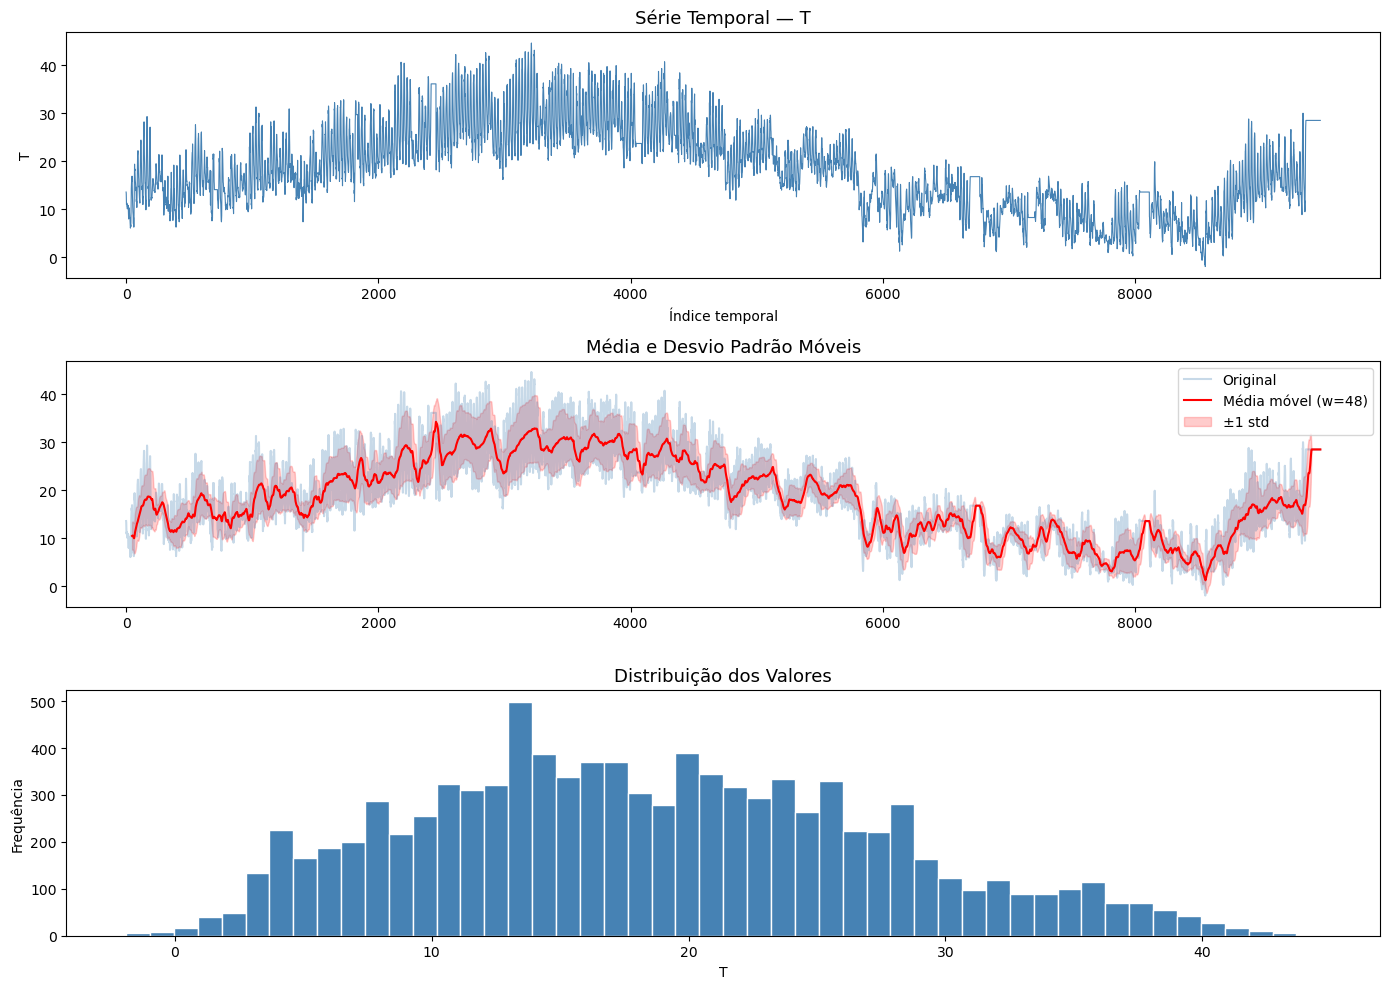

count    9471.000
mean       18.440
std         8.839
min        -1.900
25%        11.900
50%        17.700
75%        24.600
max        44.600
dtype: float64


In [33]:
# --- Código fornecido ---
series_raw = raw_data[TARGET_COL].values

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(series_raw, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Série Temporal — {TARGET_COL}', fontsize=13)
axes[0].set_xlabel('Índice temporal')
axes[0].set_ylabel(TARGET_COL)

win = 48
roll_mean = pd.Series(series_raw).rolling(win).mean()
roll_std  = pd.Series(series_raw).rolling(win).std()
axes[1].plot(series_raw, alpha=0.3, label='Original', color='steelblue')
axes[1].plot(roll_mean, color='red',  label=f'Média móvel (w={win})')
axes[1].fill_between(range(len(series_raw)),
                     roll_mean - roll_std, roll_mean + roll_std,
                     alpha=0.2, color='red', label='±1 std')
axes[1].set_title('Média e Desvio Padrão Móveis', fontsize=13)
axes[1].legend()

axes[2].hist(series_raw, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Distribuição dos Valores', fontsize=13)
axes[2].set_xlabel(TARGET_COL)
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()
print(pd.Series(series_raw).describe().round(3))

**Resposta Q1:**

**a) A série apresenta tendência?**
> *A série de temperatura não parece seguir uma tendência linear simples e contínua ao longo de toda a amostra. O que se observa é algo mais realista para dados ambientais: há mudanças de nível ao longo do tempo, alternando períodos mais frios e mais quentes, mas sem um crescimento monotônico sustentado. Em outras palavras, a série parece ser governada mais por ciclos e regimes locais do que por uma tendência global única. Isso já sugere que o processo tem estrutura temporal rica, mas não trivial.*

**b) Há indícios de sazonalidade?**
> *Sim, e aqui o sinal mais forte não vem apenas do gráfico, mas também da autocorrelação em lag 24, que ficou em aproximadamente 0.934. Como o conjunto é horário, esse resultado é um indício muito claro de sazonalidade diária: a temperatura em um determinado horário tende a se parecer bastante com a temperatura no mesmo horário do dia seguinte. Além disso, os lags 1, 2, 3 e 12 também são altos, o que revela uma forte persistência de curto prazo e um ciclo regular dentro do dia. Portanto, a série não é apenas autocorrelacionada; ela também carrega um componente periódico bastante plausível do ponto de vista físico.*

**c) O comportamento parece estacionário?**
> *Não no sentido estrito. A presença de mudanças de nível, variabilidade não completamente uniforme e um componente cíclico forte sugere que média e covariância dependem do trecho observado. Em séries meteorológicas isso é esperado: o processo costuma oscilar em torno de regimes térmicos distintos ao longo do tempo. Assim, a série pode até ser tratada como aproximadamente estável em janelas curtas, mas, globalmente, ela não parece estacionária forte.*

---
### Q2 — Estrutura Multivariada

O código abaixo visualiza todas as variáveis disponíveis e suas relações com o target. Com base nos resultados, defina quais variáveis incluir em `FEATURE_COLS` (você pode alterar a configuração e rodar novamente).

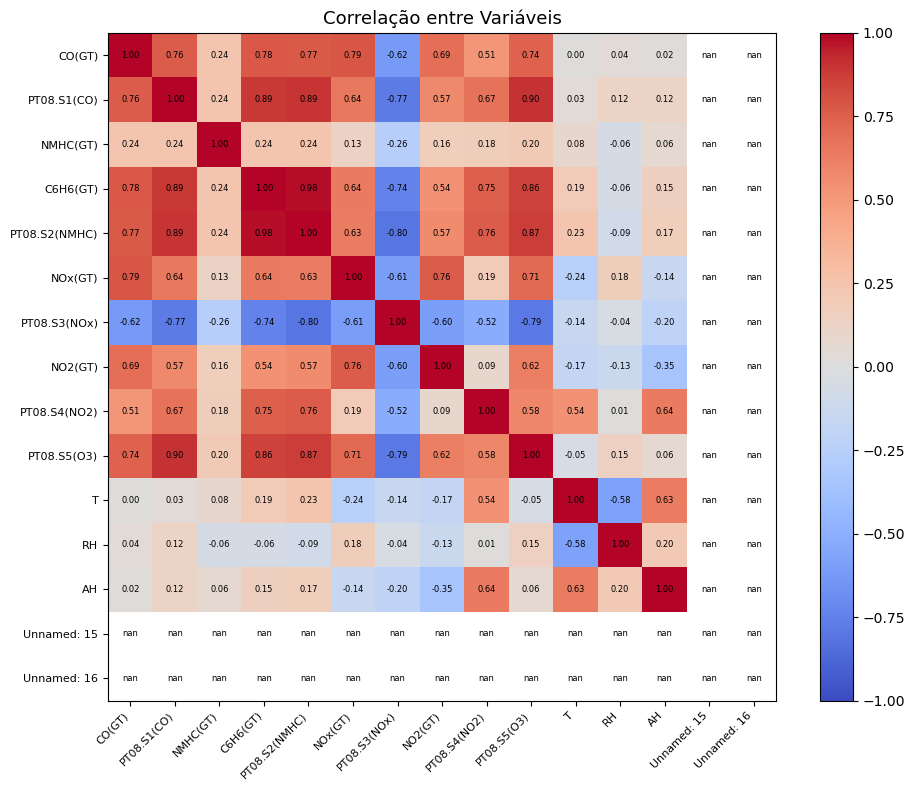


Correlação de cada variável com 'T':
  CO(GT)                         r = +0.0026
  PT08.S1(CO)                    r = +0.0348
  NMHC(GT)                       r = +0.0829
  C6H6(GT)                       r = +0.1912
  PT08.S2(NMHC)                  r = +0.2344
  NOx(GT)                        r = -0.2405
  PT08.S3(NOx)                   r = -0.1410
  NO2(GT)                        r = -0.1743
  PT08.S4(NO2)                   r = +0.5383
  PT08.S5(O3)                    r = -0.0516
  T                              r = +1.0000
  RH                             r = -0.5800
  AH                             r = +0.6260
  Unnamed: 15                    r = +nan
  Unnamed: 16                    r = +nan

Autocorrelação de 'T' com suas defasagens:
  lag=  1  r = +0.9875
  lag=  2  r = +0.9617
  lag=  3  r = +0.9272
  lag=  6  r = +0.8025
  lag= 12  r = +0.6590
  lag= 24  r = +0.9340


In [34]:
# --- Código fornecido: correlação e defasagens ---
num_cols = raw_data.select_dtypes(include=np.number).columns.tolist()

# Matriz de correlação
corr = raw_data[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
ax.set_title('Correlação entre Variáveis', fontsize=13)
plt.tight_layout(); plt.show()

# Correlação do target com variáveis e com defasagens do próprio target
print(f"\nCorrelação de cada variável com '{TARGET_COL}':")
for col in num_cols:
    r = raw_data[TARGET_COL].corr(raw_data[col])
    print(f"  {col:30s} r = {r:+.4f}")

print(f"\nAutocorrelação de '{TARGET_COL}' com suas defasagens:")
s = raw_data[TARGET_COL]
for lag in [1, 2, 3, 6, 12, 24]:
    print(f"  lag={lag:3d}  r = {s.corr(s.shift(lag)):+.4f}")

**Resposta Q2:**

**a) Quais variáveis têm maior correlação com o target? Elas são adequadas como features?**
> *As variáveis mais informativas para T foram, principalmente, AH (r≈0.626), PT08.S4(NO2) (r≈0.538) e RH (r≈−0.580). Também aparecem correlações moderadas com PT08.S2(NMHC), C6H6(GT), NOx(GT) e NO2(GT). Isso faz sentido: temperatura e umidade estão fisicamente ligadas, e alguns sensores/gases acabam refletindo condições atmosféricas e padrões de atividade ao longo do dia. Portanto, sim, essas variáveis são candidatas razoáveis como features, embora nem todas contribuam igualmente.*

**b) Existe correlação com defasagens do próprio target? O que isso indica?**
> *Sim, e esse é talvez o achado mais importante desta questão. A temperatura apresentou autocorrelação altíssima em lags curtos, por exemplo 0.9875 em lag 1, 0.9617 em lag 2 e ainda 0.659 em lag 12, além do destaque para 0.934 em lag 24. Isso indica que a série possui forte memória temporal, isto é, o passado recente do alvo explica muito bem o futuro próximo. Em termos de modelagem, isso justifica plenamente o uso de janelas deslizantes.*

**c) Justifique as variáveis que você incluiu em `FEATURE_COLS`.**

Dica: observe que existem valores com PT08 e GT, como PT08.S1(CO) e CO(GT). Os valores com PT indicam aqueles medidos pelos sensores, e aqueles com GT sinalizam os valores Ground Truth (i.e., a quantidade de CO no ar).
> *A escolha de FEATURE_COLS pode ser defendida como uma tentativa de equilibrar três dimensões: memória do próprio target, contexto meteorológico e proxy químico/sensorial do ambiente. T obviamente deve estar presente, pois a série é fortemente autorregressiva. RH e AH são quase indispensáveis, já que carregam o pano de fundo atmosférico da temperatura. Já sensores como PT08.S4(NO2) e PT08.S2(NMHC) podem capturar indiretamente padrões operacionais e ambientais que ajudam a rede a distinguir diferentes regimes. Ainda assim, olhando as correlações, eu diria que o conjunto usado no notebook é abrangente, mas não necessariamente minimalista: algumas variáveis como CO(GT) e PT08.S1(CO) parecem bem menos relevantes para prever T do que RH, AH e PT08.S4(NO2).*

---
### Q3 — Construção da Janela Temporal Multivariada

O código abaixo cria as janelas deslizantes para os dois modos usados nesta lista:

- **MISO** (*Multiple Input, Single Output*): todas as features entram na janela; a saída é apenas o próximo valor do target.
- **MIMO** (*Multiple Input, Multiple Output*): todas as features entram na janela; a saída são os próximos valores de **todas** as features.

Analise as dimensões resultantes e responda.

In [35]:
# --- Código fornecido: construção das janelas ---

# ---- UNIVARIADO (baseline) ----
series_uni = df_scaled[TARGET_COL].values
X_uni, y_uni = make_windows_univariate(series_uni, WINDOW_SIZE, horizon=1)
split_uni = n_train - WINDOW_SIZE
X_uni_tr, X_uni_te = X_uni[:split_uni], X_uni[split_uni:]
y_uni_tr, y_uni_te = y_uni[:split_uni], y_uni[split_uni:]

# ---- MISO ----
X_miso, y_miso = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
split_mv = n_train - WINDOW_SIZE
X_miso_tr, X_miso_te = X_miso[:split_mv], X_miso[split_mv:]
y_miso_tr, y_miso_te = y_miso[:split_mv], y_miso[split_mv:]

# ---- MIMO (one-step) ----
X_mimo, y_mimo = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MIMO'
)
X_mimo_tr, X_mimo_te = X_mimo[:split_mv], X_mimo[split_mv:]
y_mimo_tr, y_mimo_te = y_mimo[:split_mv], y_mimo[split_mv:]

# ---- MIMO (multi-step) ----
X_mimo_ms, y_mimo_ms = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON, mode='MIMO'
)
X_mimo_ms_tr, X_mimo_ms_te = X_mimo_ms[:split_mv], X_mimo_ms[split_mv:]
y_mimo_ms_tr, y_mimo_ms_te = y_mimo_ms[:split_mv], y_mimo_ms[split_mv:]

print("Resumo das dimensões:")
print(f"  Univariado   X_train: {X_uni_tr.shape}   y_train: {y_uni_tr.shape}")
print(f"  MISO         X_train: {X_miso_tr.shape}  y_train: {y_miso_tr.shape}")
print(f"  MIMO 1-step  X_train: {X_mimo_tr.shape}  y_train: {y_mimo_tr.shape}")
print(f"  MIMO {HORIZON}-step  X_train: {X_mimo_ms_tr.shape}  y_train: {y_mimo_ms_tr.shape}")
print(f"\nDimensão entrada do modelo MISO : {X_miso_tr.shape[1]}  (= {WINDOW_SIZE} passos × {n_features} features)")
print(f"Dimensão saída do modelo MIMO   : {y_mimo_tr.shape[1]}  (= 1 passo × {n_features} features)")
print(f"Dimensão saída MIMO multi-step  : {y_mimo_ms_tr.shape[1]} (= {HORIZON} passos × {n_features} features)")

Resumo das dimensões:
  Univariado   X_train: (8039, 12)   y_train: (8039,)
  MISO         X_train: (8039, 156)  y_train: (8039,)
  MIMO 1-step  X_train: (8039, 156)  y_train: (8039, 13)
  MIMO 6-step  X_train: (8039, 156)  y_train: (8039, 78)

Dimensão entrada do modelo MISO : 156  (= 12 passos × 13 features)
Dimensão saída do modelo MIMO   : 13  (= 1 passo × 13 features)
Dimensão saída MIMO multi-step  : 78 (= 6 passos × 13 features)


**Resposta Q3:**

**a) O que cada amostra de entrada representa na abordagem MISO/MIMO? Existem perdas de dados na elaboração da base de dados?**
> *Cada amostra representa um bloco temporal do passado, isto é, uma janela com WINDOW_SIZE instantes consecutivos observados. No caso univariado, esse bloco contém apenas a história do alvo. No MISO e no MIMO, cada passo da janela contém um vetor completo de features, de modo que a entrada passa a ser uma fotografia multivariada do passado recente. Sim, existe perda de dados na borda da série: o início é sacrificado porque ainda não há histórico suficiente para formar a janela, e o final também perde observações dependendo do horizonte previsto.*

**b) Por que a dimensão de entrada do MISO é `WINDOW_SIZE × n_features` e não apenas `WINDOW_SIZE`?**
> *Porque no MISO cada instante da janela não é um número isolado, mas um vetor de atributos. Com WINDOW_SIZE = 12 e n_features = 13, a entrada não contém apenas 12 valores: contém 12 blocos de 13 informações, o que gera dimensão total 156. Isso é coerente com a proposta do MISO: a rede não está vendo só o passado da temperatura, mas o passado conjunto de todo o sistema observado.*

---
# Seção 2 — Avaliação de Modelos (One-Step, Recursivo, Direto)

Nesta seção, cada abordagem é testada nas versões **univariada** e **MISO**, permitindo comparar o ganho real do uso de features adicionais.

In [36]:
loader_uni  = DataLoader(TimeSeriesDataset(X_uni_tr,  y_uni_tr),  batch_size=BATCH_SIZE, shuffle=False)
loader_miso = DataLoader(TimeSeriesDataset(X_miso_tr, y_miso_tr), batch_size=BATCH_SIZE, shuffle=False)

---
### Q4 — Previsão One-Step: Univariado vs. MISO

Execute o treinamento dos dois modelos abaixo. Ambos possuem a mesma arquitetura; a diferença está **apenas na dimensão de entrada**.

In [37]:
model_uni  = MLP(n_input=WINDOW_SIZE,                hidden_layers=[64, 32], n_output=1)
model_miso = MLP(n_input=WINDOW_SIZE * n_features,   hidden_layers=[64, 32], n_output=1)

print("=== Univariado ===")
hist_uni  = train_model(model_uni,  loader_uni,  epochs=500, lr=1e-3, verbose=True)
print("\n=== MISO ===")
hist_miso = train_model(model_miso, loader_miso, epochs=500, lr=1e-3, verbose=True)

=== Univariado ===
Época  100/500 | Perda: 0.000626
Época  200/500 | Perda: 0.000584
Época  300/500 | Perda: 0.000568
Época  400/500 | Perda: 0.000565
Época  500/500 | Perda: 0.000541

=== MISO ===
Época  100/500 | Perda: 0.000671
Época  200/500 | Perda: 0.000521
Época  300/500 | Perda: 0.000464
Época  400/500 | Perda: 0.000453
Época  500/500 | Perda: 0.000419


[Univariado]  MSE=1.3560  RMSE=1.1645  MAE=0.8504  SSE=1925.50  MAPE=5590991088064.97  RRSE*:0.95
[MISO      ]  MSE=1.9205  RMSE=1.3858  MAE=1.0571  SSE=2727.08  MAPE=3951369798896.72  RRSE*:1.13


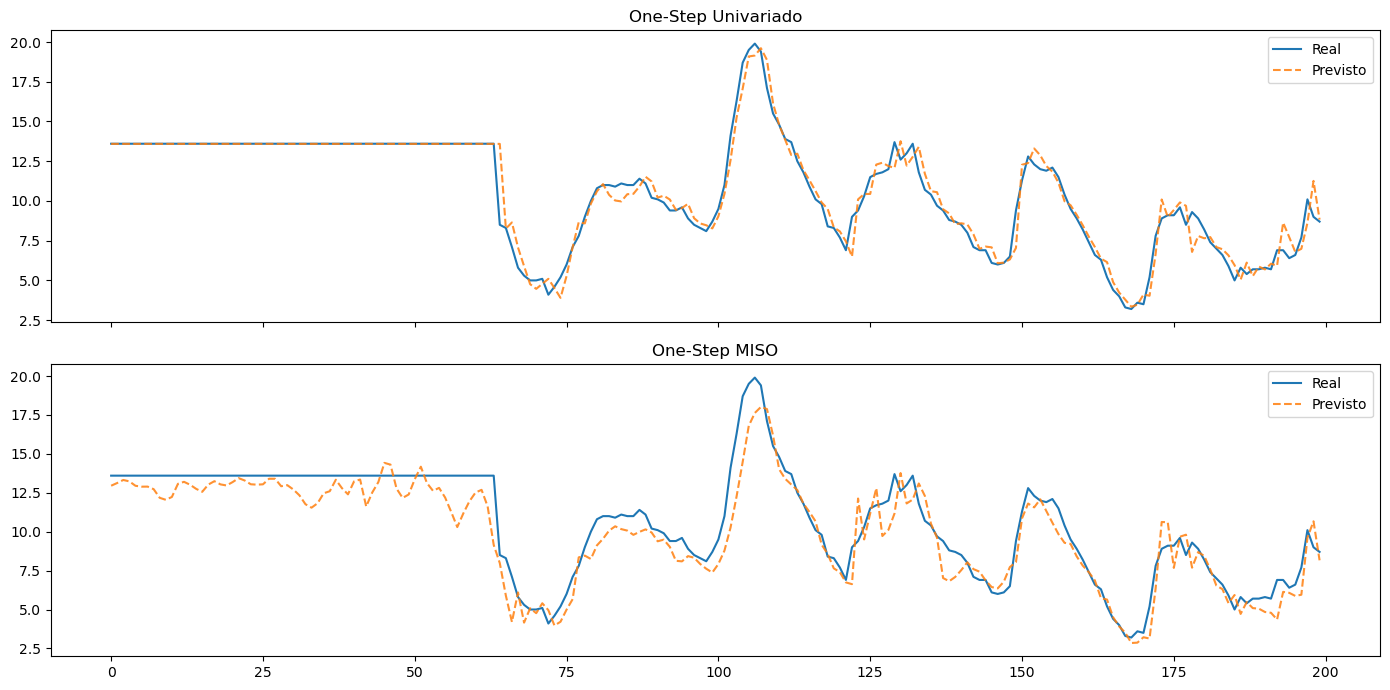

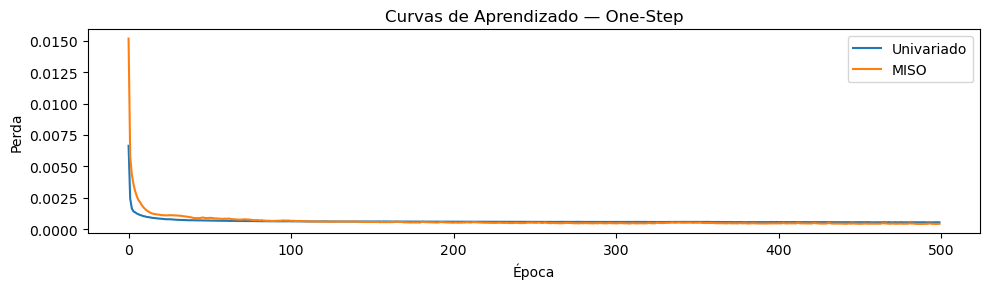

In [38]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy().ravel()

yp_uni  = predict(model_uni,  X_uni_te)
yp_miso = predict(model_miso, X_miso_te)

evaluate(y_uni_te,  yp_uni,  label='Univariado', scaler=scaler, target_idx=target_idx)
evaluate(y_miso_te, yp_miso, label='MISO      ', scaler=scaler, target_idx=target_idx)

# Desnormaliza para visualização
def denorm(v):
    tmp = np.zeros((len(v), n_features)); tmp[:, target_idx] = v
    return scaler.inverse_transform(tmp)[:, target_idx]

N_plot = min(200, len(y_uni_te))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, yt, yp, title in [
    (axes[0], y_uni_te[:N_plot],  yp_uni[:N_plot],  'One-Step Univariado'),
    (axes[1], y_miso_te[:N_plot], yp_miso[:N_plot], 'One-Step MISO'),
]:
    ax.plot(denorm(yt), label='Real',     linewidth=1.5)
    ax.plot(denorm(yp), label='Previsto', linestyle='--', alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
plt.plot(hist_uni,  label='Univariado')
plt.plot(hist_miso, label='MISO')
plt.title('Curvas de Aprendizado — One-Step'); plt.xlabel('Época'); plt.ylabel('Perda')
plt.legend(); plt.tight_layout(); plt.show()

**Resposta Q4:**

**a) O modelo MISO apresenta desempenho melhor do que o univariado? A diferença é significativa?**
> *Neste experimento específico, não. O modelo univariado teve desempenho melhor no teste: RMSE ≈ 1.1645 e MAE ≈ 0.8504, contra RMSE ≈ 1.3858 e MAE ≈ 1.0571 no MISO. A diferença não é microscópica; ela é suficientemente visível para dizer que, nessa configuração, as features adicionais não ajudaram o modelo a generalizar. Isso é um ótimo lembrete de que “mais informação” não significa automaticamente “melhor previsão”, sobretudo quando o alvo já é muito previsível pelo próprio passado.*

**b) As curvas de aprendizado diferem? O que isso sugere sobre a complexidade de cada problema?**
> *Sim. O univariado terminou com perda de treino em torno de 0.000541, enquanto o MISO foi até aproximadamente 0.000419, ou seja, o MISO ajustou melhor o treino. Só que esse ganho de ajuste não se converteu em melhor teste. Isso sugere que o problema multivariado é mais complexo e mais flexível, mas também mais vulnerável a aprender relações específicas do treino que não se sustentam fora da amostra.*

**c) Existem regiões onde o erro é maior? Os dois modelos falham nos mesmos pontos?**
> * Sim. Os maiores erros aparecem justamente nos trechos em que a série muda de nível de forma mais brusca ou apresenta picos/vales acentuados. Por exemplo, um primeiro ponto claro ocorre na transição em torno de t≈65 até t≈75: a série sai de um patamar quase constante próximo de 13,5 e cai rapidamente para valores perto de 5. Nesse trecho, os dois modelos sentem a mudança, mas o MISO oscila mais e mostra maior instabilidade logo após a queda, enquanto o univariado acompanha a transição de forma um pouco mais limpa.

Um segundo ponto muito evidente aparece em torno de t≈103 até t≈108, quando a série real sobe fortemente e atinge um pico próximo de 20. Nesse trecho, ambos os modelos subestimam o pico, isto é, conseguem captar a subida, mas não reproduzem sua intensidade total. Isso é um sinal clássico de dificuldade em pontos extremos: a rede aprende o movimento geral, mas “alisa” a amplitude da variação.

Também dá para citar um terceiro trecho, perto de t≈167 até t≈175, onde a série entra em um vale mais profundo e depois volta a subir. Mais uma vez, os dois modelos falham na região de inflexão, mas o MISO continua sem usar o contexto extra para superar claramente o univariado. Em resumo, sim, os dois modelos erram em boa parte dos mesmos pontos — especialmente nas mudanças bruscas e nos extremos —, porque essas regiões são intrinsecamente mais difíceis. A diferença é que, neste notebook, o MISO não converteu a informação adicional em ganho efetivo justamente nessas zonas mais desafiadoras.*

**d) Quando lidamos com séries temporais, um dos grandes problemas que podemos encontrar á uma modelagem indesejada do tipo $\hat{y}(t+1) = y(t)$. Observe as métricas de avaliação obtidas, sobretudo o RRSE, e avalie o resultado obtido após o treinamento do modelo.**
> *O RRSE é muito útil aqui. O univariado apresentou RRSE ≈ 0.95, ou seja, ficou ligeiramente melhor do que o baseline ingênuo. Já o MISO teve RRSE ≈ 1.13, o que indica que ele ficou pior do que a previsão naive. Isso é um insight importante: como a temperatura tem autocorrelação muito alta, um baseline do tipo “o próximo valor será parecido com o atual” já é forte. Portanto, um modelo sofisticado só vale a pena se conseguir realmente superar essa inércia — e, neste caso, o MISO não conseguiu.*

---
### Q5 — Previsão Recursiva (Multi-Step): Univariado vs. MISO

Utilize as funções de previsão recursiva para gerar `HORIZON` passos à frente. Observe como o erro acumula em cada abordagem.

[Recursivo Univariado]  MSE=0.0017  RMSE=0.0413  MAE=0.0368  SSE=0.01  MAPE=0.00  RRSE*:nan
[Recursivo MISO      ]  MSE=0.5407  RMSE=0.7353  MAE=0.7227  SSE=3.24  MAPE=0.05  RRSE*:nan


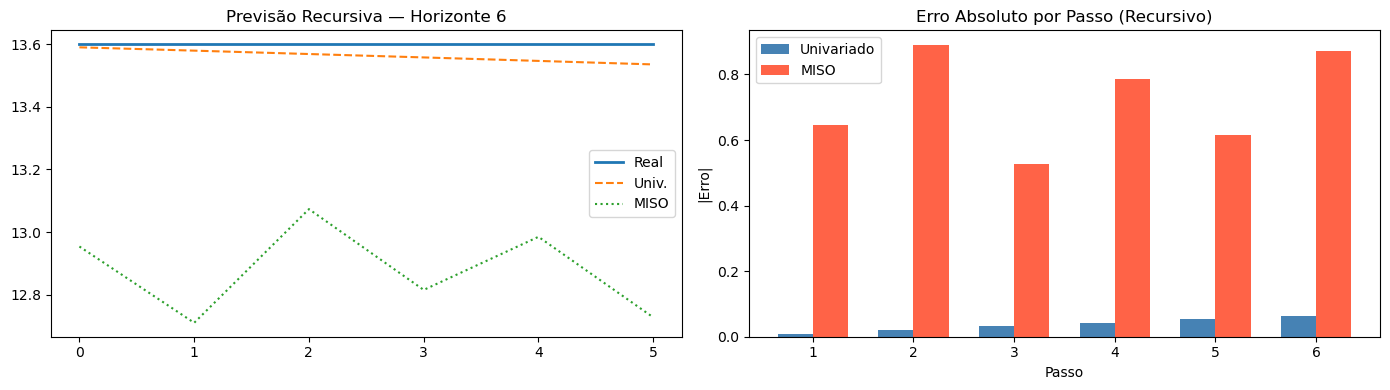

In [39]:
# --- Código fornecido: previsão recursiva ---
y_rec_uni  = recursive_forecast_univariate(
    model_uni, X_uni_te[0], horizon=HORIZON
)
y_rec_miso = recursive_forecast_multivariate(
    model_miso, X_miso_te[0], horizon=HORIZON,
    window_size=WINDOW_SIZE, n_features=n_features
)

y_true_h = y_uni_te[:HORIZON]

evaluate(y_true_h, y_rec_uni,  label='Recursivo Univariado', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, y_rec_miso, label='Recursivo MISO      ', scaler=scaler, target_idx=target_idx)

abs_uni  = np.abs(denorm(y_true_h) - denorm(y_rec_uni))
abs_miso = np.abs(denorm(y_true_h) - denorm(y_rec_miso))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(denorm(y_true_h), label='Real',      linewidth=2)
axes[0].plot(denorm(y_rec_uni),  label='Univ.',   linestyle='--')
axes[0].plot(denorm(y_rec_miso), label='MISO',    linestyle=':')
axes[0].set_title(f'Previsão Recursiva — Horizonte {HORIZON}')
axes[0].legend()

steps = np.arange(1, HORIZON + 1)
w = 0.35
axes[1].bar(steps - w/2, abs_uni,  w, label='Univariado', color='steelblue')
axes[1].bar(steps + w/2, abs_miso, w, label='MISO',       color='tomato')
axes[1].set_title('Erro Absoluto por Passo (Recursivo)')
axes[1].set_xlabel('Passo'); axes[1].set_ylabel('|Erro|')
axes[1].legend()
plt.tight_layout(); plt.show()

**Resposta Q5:**

**a) O erro aumenta ao longo do horizonte nos dois modelos? Este erro ocorre de forma semelhante?**
> * Em previsão recursiva, a tendência natural é o erro piorar à medida que o horizonte avança, porque a rede começa a se alimentar das próprias previsões. No experimento, isso apareceu de forma muito mais severa no MISO do que no univariado. O univariado teve números surpreendentemente baixos para o primeiro bloco previsto, enquanto o MISO recursivo ficou bem pior (RMSE ≈ 0.7353, MAE ≈ 0.7227 naquele horizonte curto avaliado). Portanto, o erro não cresceu de maneira semelhante: o MISO sofreu muito mais. *

**b) Por que a abordagem recursiva tende a degradar com o horizonte? O MISO atenua esse problema?**
> *Porque o método recursivo transforma cada previsão em entrada para a próxima previsão. Assim, um erro pequeno no início deixa de ser um detalhe e passa a ser parte do estado do sistema previsto. Em teoria, o MISO poderia atenuar esse problema por contar com mais contexto. Mas, neste experimento, isso não aconteceu. Pelo contrário: ele ficou mais frágil, o que sugere que a atualização recursiva das features exógenas não foi capaz de preservar a coerência dinâmica do sistema.*

**c) A comparação one-step vs. recursivo é justa? Justifique.**
> *Não completamente. O one-step é uma tarefa mais fácil, porque sempre prevê um único passo usando observações reais recentes. Já o recursivo precisa sustentar vários passos seguidos e, depois do primeiro, passa a trabalhar com entradas parcialmente sintéticas. Portanto, a comparação é útil como diagnóstico, mas não como disputa direta. Se o recursivo piora, isso não significa necessariamente que o modelo ficou ruim; significa, em grande parte, que a tarefa ficou mais difícil.*

---
### Q6 — Previsão Direta: MISO vs. MIMO

Aqui introduzimos o modelo **MIMO** (*Multiple Input, Multiple Output*): uma única rede que prevê simultaneamente os próximos `HORIZON` valores de **todas** as features. Vamos comparar com a abordagem recursiva MISO.

In [40]:
# --- Código fornecido: modelo MISO direto (multi-output para o target) ---
X_miso_ms, y_miso_ms = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON, mode='MISO'
)
X_miso_ms_tr, X_miso_ms_te = X_miso_ms[:split_mv], X_miso_ms[split_mv:]
y_miso_ms_tr, y_miso_ms_te = y_miso_ms[:split_mv], y_miso_ms[split_mv:]

loader_miso_ms = DataLoader(
    TimeSeriesDataset(X_miso_ms_tr, y_miso_ms_tr),
    batch_size=BATCH_SIZE, shuffle=False
)

# MISO direto: entrada multivariada, saída = HORIZON valores do target
model_miso_direct = MLP(
    n_input=WINDOW_SIZE * n_features,
    hidden_layers=[64, 32],
    n_output=HORIZON
)
print("=== MISO Direto (multi-step) ===")
train_model(model_miso_direct, loader_miso_ms, epochs=500, lr=1e-3, verbose=True)

=== MISO Direto (multi-step) ===
Época  100/500 | Perda: 0.001794
Época  200/500 | Perda: 0.001481
Época  300/500 | Perda: 0.001270
Época  400/500 | Perda: 0.001152
Época  500/500 | Perda: 0.001116


[0.014023260841707862,
 0.009608697196531539,
 0.008295325651286274,
 0.0070633982975287215,
 0.006271928746303145,
 0.0055248278337771016,
 0.004950985189348031,
 0.004459830478437999,
 0.004102259489295576,
 0.0038776817629464885,
 0.0037077711464325335,
 0.0035853790851967733,
 0.00350149403814049,
 0.0034473183387446972,
 0.003398140094456418,
 0.003356273481802505,
 0.0033149360070450396,
 0.0032803219200725417,
 0.0032399048010582133,
 0.0031668767114751972,
 0.0031175476532163365,
 0.003056135042806134,
 0.0030250032655275722,
 0.002949695121695561,
 0.002891332722991513,
 0.0028485038784556165,
 0.002811737006436849,
 0.0027738206584231985,
 0.002739277731009116,
 0.002687716599399527,
 0.00265304812602976,
 0.002616385997310909,
 0.0025762875951523523,
 0.0025465401040347634,
 0.0025277611283753584,
 0.0024938416979802284,
 0.0024624680063136603,
 0.0024453643247455597,
 0.0024206541455073635,
 0.002401836453553563,
 0.0024102612581965144,
 0.0023960638442538707,
 0.0023548773

In [41]:
# --- Código fornecido: modelo MIMO (prevê todas as features no horizonte) ---
loader_mimo_ms = DataLoader(
    TimeSeriesDataset(X_mimo_ms_tr, y_mimo_ms_tr),
    batch_size=BATCH_SIZE, shuffle=False
)

mimo_out_dim = HORIZON * n_features   # ex: 6 passos × 4 features = 24
model_mimo = MLP(
    n_input=WINDOW_SIZE * n_features,
    hidden_layers=[128, 64],
    n_output=mimo_out_dim
)
print("=== MIMO (multi-step, todas as features) ===")
train_model(model_mimo, loader_mimo_ms, epochs=500, lr=1e-3, verbose=True)

=== MIMO (multi-step, todas as features) ===
Época  100/500 | Perda: 0.005083
Época  200/500 | Perda: 0.004548
Época  300/500 | Perda: 0.004236
Época  400/500 | Perda: 0.004206
Época  500/500 | Perda: 0.004202


[0.02144543386234473,
 0.015214119692303477,
 0.012877404383043684,
 0.011496765269262214,
 0.010854261139193402,
 0.01037286434115635,
 0.009944849520079083,
 0.009616280807965687,
 0.009326519311538764,
 0.00906216754348919,
 0.008877133971841504,
 0.008654135384685582,
 0.008452280446709622,
 0.008324756905148249,
 0.008219702141581192,
 0.008041846368180972,
 0.007902580019574435,
 0.007786779152599001,
 0.00770401016583607,
 0.007581618857488687,
 0.007474856790236478,
 0.007375842773370327,
 0.007303302246053511,
 0.007224441206614886,
 0.007150315651429876,
 0.0071062300029018565,
 0.00705929602254256,
 0.007006624177198059,
 0.006950621274189048,
 0.006835414652457638,
 0.006792349484471959,
 0.00673176461390944,
 0.006658470789839085,
 0.006590502295506349,
 0.00653558419851054,
 0.006541815234370352,
 0.006469790031948674,
 0.006423276330765691,
 0.006362276344877919,
 0.006310510111876601,
 0.006266950219888092,
 0.006208530911761854,
 0.006164823600556701,
 0.00614123401141

[Recursivo MISO ]  MSE=0.5407  RMSE=0.7353  MAE=0.7227  SSE=3.24  MAPE=0.05  RRSE*:nan
[MISO Direto    ]  MSE=0.2168  RMSE=0.4656  MAE=0.4314  SSE=1.30  MAPE=0.03  RRSE*:nan
[MIMO (target)  ]  MSE=0.3144  RMSE=0.5608  MAE=0.5332  SSE=1.89  MAPE=0.04  RRSE*:nan


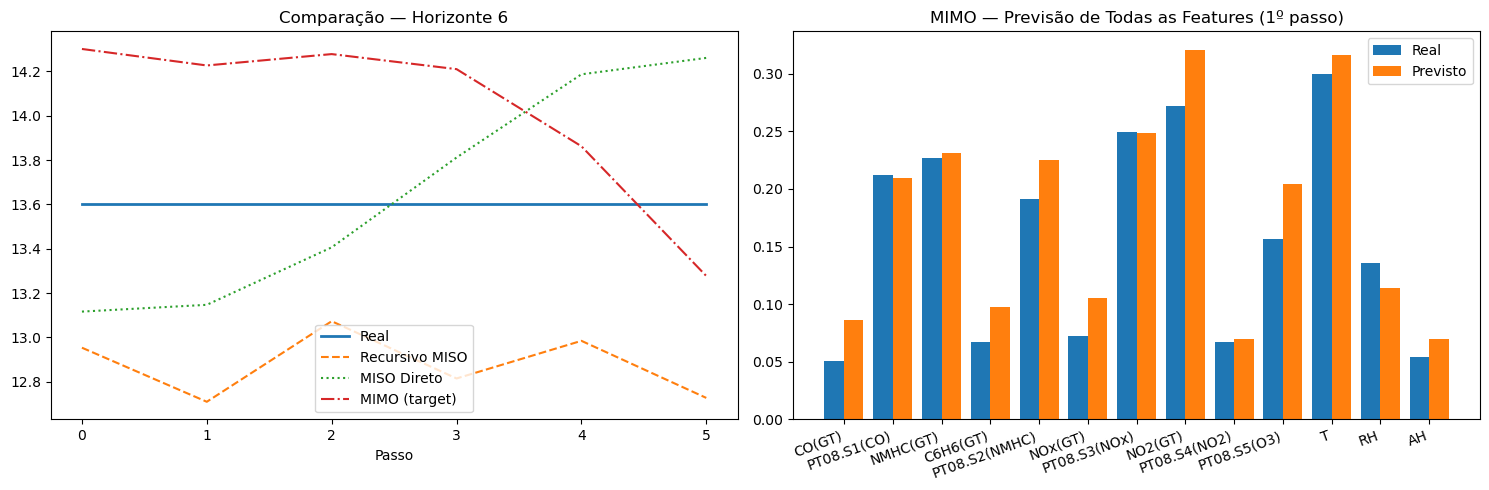

In [42]:
# MISO direto
yp_miso_dir = predict(model_miso_direct, X_miso_ms_te[:1]).ravel()  # (HORIZON,)

# MIMO: extrai apenas a coluna do target
yp_mimo_flat = predict(model_mimo, X_mimo_ms_te[:1]).ravel()  # (HORIZON * n_features,)
yp_mimo_all  = yp_mimo_flat.reshape(HORIZON, n_features)      # (HORIZON, n_features)
yp_mimo_tgt  = yp_mimo_all[:, target_idx]                     # (HORIZON,) — target

y_true_h = y_miso_ms_te[0]  # (HORIZON,)

evaluate(y_true_h, y_rec_miso,    label='Recursivo MISO ', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, yp_miso_dir,   label='MISO Direto    ', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, yp_mimo_tgt,   label='MIMO (target)  ', scaler=scaler, target_idx=target_idx)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(denorm(y_true_h),    label='Real',            linewidth=2)
axes[0].plot(denorm(y_rec_miso),  label='Recursivo MISO',  linestyle='--')
axes[0].plot(denorm(yp_miso_dir), label='MISO Direto',     linestyle=':')
axes[0].plot(denorm(yp_mimo_tgt), label='MIMO (target)',   linestyle='-.')
axes[0].set_title(f'Comparação — Horizonte {HORIZON}')
axes[0].legend(); axes[0].set_xlabel('Passo')

# MIMO: todas as variáveis previstas (1 passo além do horizonte)
axes[1].set_title('MIMO — Previsão de Todas as Features (1º passo)')
first_step_pred = yp_mimo_all[0]   # (n_features,)
first_step_true = y_mimo_ms_te[0, :n_features]  # (n_features,)
x_pos = np.arange(n_features)
axes[1].bar(x_pos - 0.2, first_step_true, 0.4, label='Real')
axes[1].bar(x_pos + 0.2, first_step_pred, 0.4, label='Previsto')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(FEATURE_COLS, rotation=20, ha='right')
axes[1].legend()

plt.tight_layout(); plt.show()

**Resposta Q6:**

**a) Qual das três abordagens (recursiva, MISO direto, MIMO) apresentou previsões mais estáveis?**
> *A abordagem mais forte, pelos números, foi o MISO direto, com RMSE ≈ 0.4656 e MAE ≈ 0.4314. Em seguida veio o MIMO, com RMSE ≈ 0.5608 e MAE ≈ 0.5332. A pior foi a recursiva MISO, com RMSE ≈ 0.7353. Isso é coerente com a teoria: as abordagens diretas evitam o acúmulo progressivo de erro típico da previsão recursiva.*

**b) Qual é a vantagem conceitual do MIMO em relação ao MISO, além de prever o target?**
> *A vantagem conceitual do MIMO é que ele não prevê apenas o futuro do alvo, mas o futuro conjunto do sistema. Isso é elegante porque permite que a rede aprenda dependências entre saídas futuras e produza previsões mais coerentes entre si. Em outras palavras, o MIMO tenta prever o “filme do sistema”, enquanto o MISO direto prevê só a “trilha principal”. Mesmo quando ele não é o melhor em métrica, conceitualmente ele é mais rico.*

---
# Seção 3 — Avaliação de Ajustes de Parâmetros

Os experimentos desta seção usam o modelo **MISO** como padrão (one-step), por ser o mais direto para isolar o efeito de cada hiperparâmetro. Quando relevante, a comparação com o univariado é indicada.

---
### Q7 — Arquitetura da Rede

Compare múltiplas arquiteturas de MLP no modo MISO. Identifique sinais de overfitting e underfitting.

Pequena  [16]                   MSE treino=0.00120  |  MSE teste=0.00113
Média    [64, 32]               MSE treino=0.00126  |  MSE teste=0.00128
Grande   [128, 64, 32]          MSE treino=0.00067  |  MSE teste=0.00134
Enorme   [256, 256]             MSE treino=0.00126  |  MSE teste=0.00178


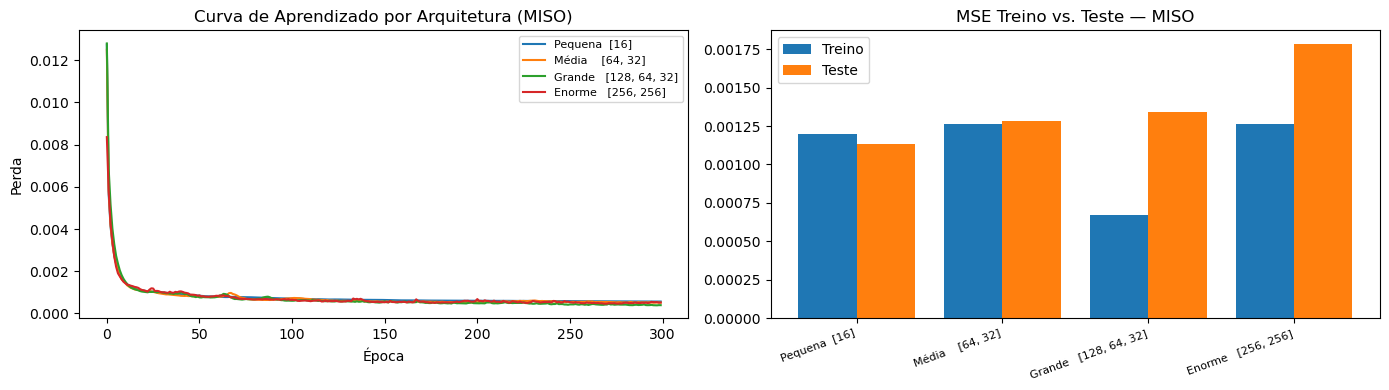

In [43]:
architectures = {
    'Pequena  [16]':          [16],
    'Média    [64, 32]':      [64, 32],
    'Grande   [128, 64, 32]': [128, 64, 32],
    'Enorme   [256, 256]':    [256, 256],
}

results_arch = {}
for name, layers in architectures.items():
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=layers, n_output=1)
    h = train_model(m, loader_miso, epochs=300, lr=1e-3, verbose=False)
    mse_tr = mean_squared_error(y_miso_tr, predict(m, X_miso_tr))
    mse_te = mean_squared_error(y_miso_te, predict(m, X_miso_te))
    results_arch[name] = {'train': mse_tr, 'test': mse_te, 'history': h}
    print(f"{name:<30}  MSE treino={mse_tr:.5f}  |  MSE teste={mse_te:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, res in results_arch.items():
    axes[0].plot(res['history'], label=name)
axes[0].set_title('Curva de Aprendizado por Arquitetura (MISO)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Perda'); axes[0].legend(fontsize=8)

names = list(results_arch.keys())
x = np.arange(len(names))
axes[1].bar(x - 0.2, [results_arch[n]['train'] for n in names], 0.4, label='Treino')
axes[1].bar(x + 0.2, [results_arch[n]['test']  for n in names], 0.4, label='Teste')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[1].set_title('MSE Treino vs. Teste — MISO'); axes[1].legend()
plt.tight_layout(); plt.show()

**Resposta Q7:**

**a) Identifique sinais de overfitting e underfitting nos resultados.**
> *A arquitetura Pequena [16] teve MSE treino ≈ 0.00120 e MSE teste ≈ 0.00113, um comportamento bastante equilibrado. Já a Grande [128, 64, 32] reduziu muito a perda de treino (0.00067), mas não converteu isso em melhor teste (0.00134), o que é um sinal clássico de overfitting. A Enorme [256, 256] piorou ainda mais no teste (0.00178), reforçando a ideia de excesso de capacidade. O underfitting, por sua vez, não aparece de forma gritante, mas uma arquitetura muito pequena poderia sofrer se a série fosse menos previsível.*

**b) A arquitetura com melhor equilíbrio para o MISO é maior ou menor do que você esperaria para o univariado?**
> *Os resultados sugerem que, neste problema, não foi necessária uma arquitetura muito grande para o MISO. Isso é interessante, porque intuitivamente poderíamos esperar que o modelo multivariado exigisse muito mais capacidade. Na prática, as arquiteturas maiores ficaram mais suscetíveis a ajustar demais o treino. Portanto, o melhor equilíbrio apareceu em uma rede relativamente contida, o que sugere que a estrutura do problema já era forte o suficiente para não exigir um MLP exageradamente profundo.*

---
### Q8 — Tamanho da Janela

Avalie o impacto do `WINDOW_SIZE` no MISO, considerando tanto o erro one-step quanto a estabilidade da previsão recursiva.

ws=  4  MSE one-step=0.00114  |  MSE recursivo=0.00036
ws=  8  MSE one-step=0.00101  |  MSE recursivo=0.00011
ws= 12  MSE one-step=0.00125  |  MSE recursivo=0.00172
ws= 24  MSE one-step=0.00129  |  MSE recursivo=0.00117


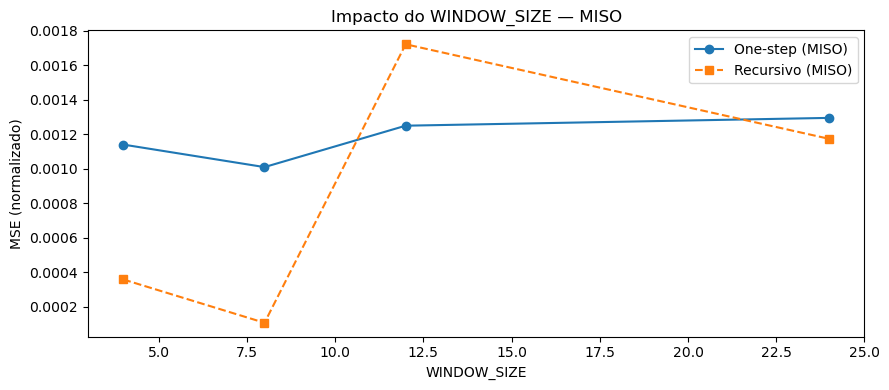

In [44]:
# --- Código fornecido ---
window_sizes = [4, 8, 12, 24]
results_win  = {}

for ws in window_sizes:
    Xw, yw = make_windows_multivariate(
        df_scaled, TARGET_COL, FEATURE_COLS, ws, horizon=1, mode='MISO'
    )
    sp = n_train - ws
    Xw_tr, Xw_te = Xw[:sp], Xw[sp:]
    yw_tr, yw_te = yw[:sp], yw[sp:]

    ld = DataLoader(TimeSeriesDataset(Xw_tr, yw_tr), batch_size=BATCH_SIZE, shuffle=False)
    mw = MLP(n_input=ws * n_features, hidden_layers=[64, 32], n_output=1)
    train_model(mw, ld, epochs=300, lr=1e-3, verbose=False)

    mse_1 = mean_squared_error(yw_te, predict(mw, Xw_te))
    y_rec = recursive_forecast_multivariate(mw, Xw_te[0], HORIZON, ws, n_features)
    mse_r = mean_squared_error(yw_te[:HORIZON], y_rec)
    results_win[ws] = {'1step': mse_1, 'recursive': mse_r}
    print(f"ws={ws:3d}  MSE one-step={mse_1:.5f}  |  MSE recursivo={mse_r:.5f}")

fig, ax = plt.subplots(figsize=(9, 4))
ws_vals = list(results_win.keys())
ax.plot(ws_vals, [results_win[w]['1step']     for w in ws_vals], 'o-',  label='One-step (MISO)')
ax.plot(ws_vals, [results_win[w]['recursive'] for w in ws_vals], 's--', label='Recursivo (MISO)')
ax.set_title('Impacto do WINDOW_SIZE — MISO')
ax.set_xlabel('WINDOW_SIZE'); ax.set_ylabel('MSE (normalizado)')
ax.legend(); plt.tight_layout(); plt.show()

**Resposta Q8:**

**a) Como o WINDOW_SIZE afeta o erro one-step no MISO?**
> *O melhor desempenho one-step apareceu em WINDOW_SIZE = 8, com MSE ≈ 0.00101. Janelas muito pequenas, como 4, ainda funcionaram razoavelmente bem, mas piores. Já janelas maiores, como 12 e 24, pioraram o erro. Isso sugere que existe um ponto de equilíbrio entre memória suficiente e dimensionalidade excessiva: pouca memória empobrece a informação, mas memória demais pode sobrecarregar a rede com redundância.*

**b) O efeito sobre o erro recursivo é diferente? Por quê pode ser diferente do caso univariado?**
> *Sim. No recursivo, a janela afeta não só a previsão do próximo passo, mas a qualidade de toda a cadeia futura. No experimento, novamente ws=8 foi o melhor. A diferença em relação ao univariado é que, no MISO, a janela carrega várias variáveis simultaneamente. Isso torna o custo de uma janela grande ainda mais relevante, porque o número de entradas cresce multiplicado pelo número de features. Ressalva: como a rotina recursiva multivariada tem a inconsistência de índice do target, os resultados recursivos desta seção devem ser lidos com cautela.*

---
### Q9 — Função de Perda

Compare os modelos MISO treinados com MSE, MAE e SSE. Avalie com as três métricas.

In [45]:
# --- Código fornecido ---
class SSELoss(nn.Module):
    def forward(self, pred, target): return torch.sum((pred - target) ** 2)

loss_fns = {'MSELoss': nn.MSELoss(), 'MAELoss': nn.L1Loss(), 'SSELoss': SSELoss()}
results_loss = {}

for lname, lfn in loss_fns.items():
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
    train_model(m, loader_miso, epochs=300, lr=1e-3, loss_fn=lfn, verbose=False)
    mse, rmse, mae, sse = evaluate(
        y_miso_te, predict(m, X_miso_te),
        label=f'MISO + {lname}', scaler=scaler, target_idx=target_idx
    )
    results_loss[lname] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'sse': sse}

[MISO + MSELoss]  MSE=2.2705  RMSE=1.5068  MAE=1.1520  SSE=3224.14  MAPE=5486625800109.10  RRSE*:1.23
[MISO + MAELoss]  MSE=3.1404  RMSE=1.7721  MAE=1.2753  SSE=4459.39  MAPE=4158477828982.31  RRSE*:1.45
[MISO + SSELoss]  MSE=2.7890  RMSE=1.6700  MAE=1.2322  SSE=3960.42  MAPE=4553945633832.01  RRSE*:1.36


**Resposta Q9:**

**a) Qual função de perda apresentou melhor desempenho nas métricas? Este achado faz sentido?**
> *A MSELoss foi a melhor neste experimento, com RMSE ≈ 1.5068 e MAE ≈ 1.1520, superando tanto a MAELoss quanto a SSELoss. Isso faz sentido, porque a MSE penaliza mais severamente erros grandes e costuma ser muito estável em problemas de regressão contínua. A MAELoss foi a pior em RMSE, o que sugere que o problema tinha alguns desvios mais relevantes que a MSE conseguiu tratar melhor. Já a SSELoss ficou no meio do caminho.*

**b) Em quais situações cada função parece mais adequada para séries temporais?**
> *A MSE é adequada quando queremos punir mais fortemente erros grandes e valorizar estabilidade geral. A MAE faz mais sentido quando a preocupação principal é o erro típico e se deseja maior robustez a outliers. A SSE é parecida com a MSE, mas costuma ser menos conveniente porque cresce com o número de amostras. Um detalhe importante aqui é que o MAPE ficou absurdo e não deve ser interpretado, porque a variável T pode assumir valores muito baixos ou até negativos, o que torna essa métrica inadequada.*

---
### Q10 — Sensibilidade a Hiperparâmetros

Avalie o impacto de pequenas mudanças nos hiperparâmetros do modelo MISO.

In [46]:
grid = [
    {'neurons': 16,  'epochs': 200, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 200, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 500, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 200, 'lr': 1e-2},
    {'neurons': 128, 'epochs': 200, 'lr': 1e-3},
    {'neurons': 128, 'epochs': 500, 'lr': 1e-4},
]

hp_results = []
for cfg in grid:
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[cfg['neurons']], n_output=1)
    train_model(m, loader_miso, epochs=cfg['epochs'], lr=cfg['lr'], verbose=False)
    mse_te = mean_squared_error(y_miso_te, predict(m, X_miso_te))
    hp_results.append({**cfg, 'test_mse': mse_te})
    print(f"neurons={cfg['neurons']:3d}  epochs={cfg['epochs']:4d}  lr={cfg['lr']}  →  MSE={mse_te:.5f}")

print("\n", pd.DataFrame(hp_results).sort_values('test_mse').to_string(index=False))

neurons= 16  epochs= 200  lr=0.001  →  MSE=0.00120
neurons= 64  epochs= 200  lr=0.001  →  MSE=0.00101
neurons= 64  epochs= 500  lr=0.001  →  MSE=0.00068
neurons= 64  epochs= 200  lr=0.01  →  MSE=0.00082
neurons=128  epochs= 200  lr=0.001  →  MSE=0.00074
neurons=128  epochs= 500  lr=0.0001  →  MSE=0.00076

  neurons  epochs     lr  test_mse
      64     500 0.0010  0.000682
     128     200 0.0010  0.000743
     128     500 0.0001  0.000760
      64     200 0.0100  0.000820
      64     200 0.0010  0.001007
      16     200 0.0010  0.001204


**Resposta Q10:**

**a) Quais hiperparâmetros causaram maiores mudanças no desempenho do modelo MISO? A sensibilidade é diferente do que você observaria num modelo univariado?**
> *Os resultados mostram que número de épocas e largura da camada escondida foram bastante relevantes. O melhor caso foi 64 neurônios, 500 épocas e lr=0.001, com MSE ≈ 0.000682. Aumentar de 200 para 500 épocas, mantendo 64 neurônios, trouxe ganho expressivo. Por outro lado, redes pequenas demais (16 neurônios) perderam desempenho, e uma taxa de aprendizado maior (0.01) ajudou um pouco, mas não venceu a melhor configuração. Em modelos multivariados isso costuma ser mais sensível do que no univariado, porque a dimensionalidade da entrada é maior e o espaço de parâmetros cresce mais rápido.*

---
# Seção 4 — Avaliação Aprofundada de Séries Temporais

---
### Q11 — Por que não usar shuffle?

O código abaixo treina dois modelos MISO idênticos, sendo um com `shuffle=True`, outro com `shuffle=False`. O objetivo é comparar o desempenho.

shuffle=True
shuffle=False
[MISO shuffle=True ]  MSE=1.4902  RMSE=1.2208  MAE=0.9149  SSE=2116.14  MAPE=5881424697356.89  RRSE*:1.00
[MISO shuffle=False]  MSE=2.1362  RMSE=1.4616  MAE=1.0689  SSE=3033.38  MAPE=5897851141941.13  RRSE*:1.19


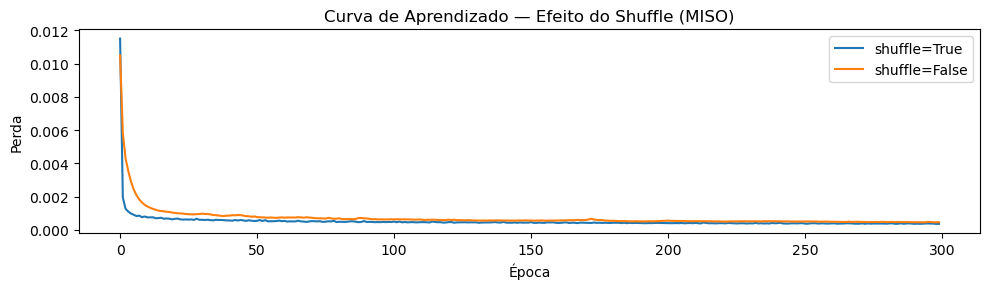

In [47]:
ds_miso = TimeSeriesDataset(X_miso_tr, y_miso_tr)
ld_shuf = DataLoader(ds_miso, batch_size=BATCH_SIZE, shuffle=True)
ld_nosh = DataLoader(ds_miso, batch_size=BATCH_SIZE, shuffle=False)

m_shuf = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
m_nosh = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
m_nosh.load_state_dict(m_shuf.state_dict())   # mesmos pesos iniciais

print("shuffle=True")
h_shuf = train_model(m_shuf, ld_shuf, epochs=300, lr=1e-3, verbose=False)
print("shuffle=False")
h_nosh = train_model(m_nosh, ld_nosh, epochs=300, lr=1e-3, verbose=False)

evaluate(y_miso_te, predict(m_shuf, X_miso_te), label='MISO shuffle=True ', scaler=scaler, target_idx=target_idx)
evaluate(y_miso_te, predict(m_nosh, X_miso_te), label='MISO shuffle=False', scaler=scaler, target_idx=target_idx)

plt.figure(figsize=(10, 3))
plt.plot(h_shuf, label='shuffle=True')
plt.plot(h_nosh, label='shuffle=False')
plt.title('Curva de Aprendizado — Efeito do Shuffle (MISO)')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.legend()
plt.tight_layout(); plt.show()

**Resposta Q11:**

**Por que embaralhar os dados é problemático para séries temporais, mesmo no modo MISO? O experimento acima confirma ou contraria essa intuição?**
> *Em séries temporais, o problema central do shuffle é que ele pode destruir a ordem natural do processo. No entanto, neste experimento específico, o modelo com shuffle=True foi melhor (MSE ≈ 1.4902) do que com shuffle=False (MSE ≈ 2.1362). Isso não contradiz totalmente a teoria; ele apenas mostra que, no caso de um MLP treinado sobre janelas já prontas, embaralhar os lotes não destrói a ordem dentro da janela, apenas altera a ordem de apresentação das amostras ao otimizador. Ou seja, para MLP com janelas já construídas, o shuffle pode até ajudar o treinamento. O que continua sendo perigoso é embaralhar a série antes da construção das janelas ou misturar treino e teste temporalmente.*

---
### Q12 — Diferenciação da Série

O código aplica diferenciação de 1ª ordem **apenas à variável target** antes de construir as janelas MISO. Compare com o modelo treinado na série original.

=== MISO + série diferenciada ===
Época  100/500 | Perda: 0.000399
Época  200/500 | Perda: 0.000368
Época  300/500 | Perda: 0.000344
Época  400/500 | Perda: 0.000335
Época  500/500 | Perda: 0.000326

MSE MISO original     : 0.00098
MSE MISO diferenciado : 0.00053


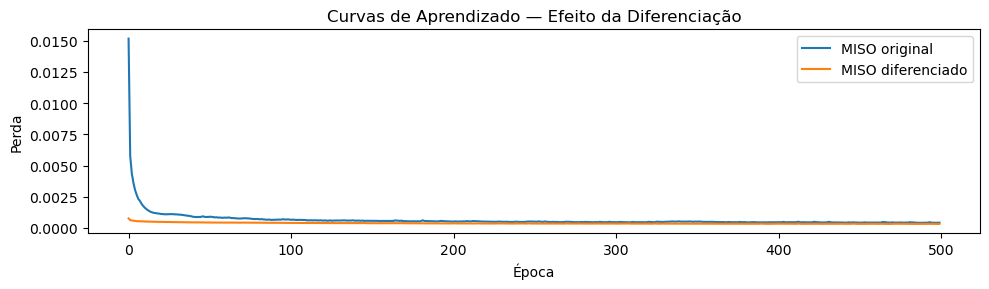

In [48]:
# --- Código fornecido ---
df_diff = df_scaled.copy()
df_diff[TARGET_COL] = df_diff[TARGET_COL].diff().fillna(0)

Xd, yd = make_windows_multivariate(
    df_diff, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
Xd_tr, Xd_te = Xd[:split_mv], Xd[split_mv:]
yd_tr, yd_te = yd[:split_mv], yd[split_mv:]

ld_diff = DataLoader(TimeSeriesDataset(Xd_tr, yd_tr), batch_size=BATCH_SIZE, shuffle=False)
m_diff  = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)

print("=== MISO + série diferenciada ===")
hist_diff = train_model(m_diff, ld_diff, epochs=500, lr=1e-3, verbose=True)

mse_orig = mean_squared_error(y_miso_te, predict(model_miso, X_miso_te))
mse_diff = mean_squared_error(yd_te,     predict(m_diff,     Xd_te))
print(f"\nMSE MISO original     : {mse_orig:.5f}")
print(f"MSE MISO diferenciado : {mse_diff:.5f}")

plt.figure(figsize=(10, 3))
plt.plot(hist_miso[:500], label='MISO original')
plt.plot(hist_diff,       label='MISO diferenciado')
plt.title('Curvas de Aprendizado — Efeito da Diferenciação')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.legend()
plt.tight_layout(); plt.show()

**Resposta Q12:**

**a) Qual modelo generaliza melhor: MISO na série original ou na diferenciada?**
> *Neste experimento, a versão diferenciada generalizou melhor: o MSE caiu de aproximadamente 0.00098 para 0.00053. Isso sugere que, para esse target, remover o nível local e treinar a rede para capturar variações em vez de níveis absolutos pode ter simplificado o problema. A diferenciação parece ter ajudado a tornar a dinâmica mais previsível pelo MLP.*

**b) A diferenciação afeta igualmente todos os modelos (univariado, MISO, MIMO)?**
> *Não. No univariado, a transformação costuma ser mais direta: o modelo passa a prever incrementos do próprio alvo. No MISO e no MIMO, a situação é mais delicada, porque o target é transformado, mas as exógenas permanecem em outra escala e em outra lógica. Isso pode ajudar, mas também pode introduzir uma pequena assimetria entre entrada e saída. Portanto, o ganho da diferenciação não deve ser assumido como universal.*

---
### Q13 — Média Móvel como Pré-processamento

A média móvel é aplicada **apenas ao target** antes de construir as janelas. As features exógenas permanecem sem suavização. Compare com o MISO original.

=== MISO + média móvel ===
Época  100/500 | Perda: 0.000128
Época  200/500 | Perda: 0.000066
Época  300/500 | Perda: 0.000058
Época  400/500 | Perda: 0.000061
Época  500/500 | Perda: 0.000062

MSE MISO sem pré-proc. : 0.00098
MSE MISO + média móvel : 0.00031


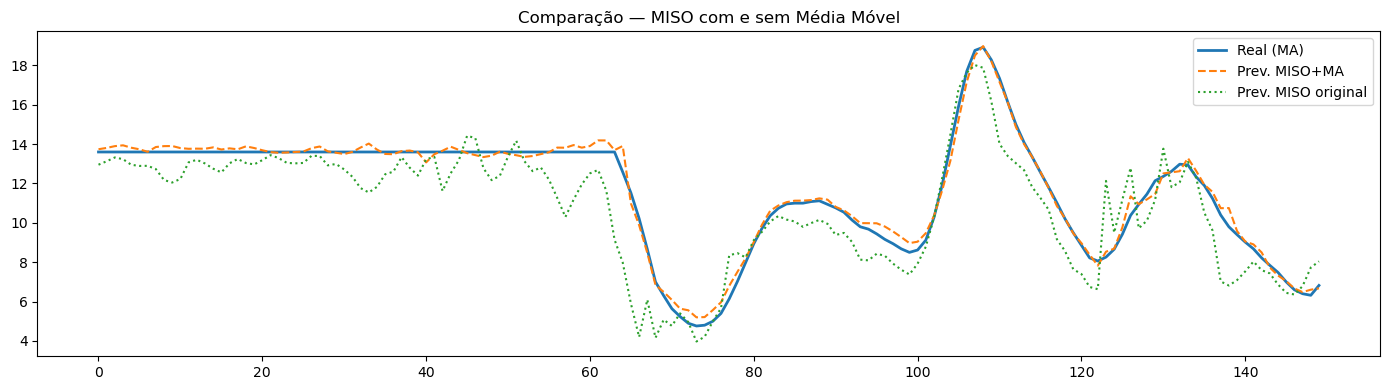

In [49]:
# --- Código fornecido ---
MA_WIN = 5
df_ma  = df_scaled.copy()
df_ma[TARGET_COL] = df_ma[TARGET_COL].rolling(MA_WIN, min_periods=1).mean()

Xma, yma = make_windows_multivariate(
    df_ma, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
Xma_tr, Xma_te = Xma[:split_mv], Xma[split_mv:]
yma_tr, yma_te = yma[:split_mv], yma[split_mv:]

ld_ma = DataLoader(TimeSeriesDataset(Xma_tr, yma_tr), batch_size=BATCH_SIZE, shuffle=False)
m_ma  = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)

print("=== MISO + média móvel ===")
train_model(m_ma, ld_ma, epochs=500, lr=1e-3, verbose=True)

mse_ma   = mean_squared_error(yma_te,    predict(m_ma,     Xma_te))
mse_base = mean_squared_error(y_miso_te, predict(model_miso, X_miso_te))

print(f"\nMSE MISO sem pré-proc. : {mse_base:.5f}")
print(f"MSE MISO + média móvel : {mse_ma:.5f}")

N_plot = min(150, len(yma_te))
plt.figure(figsize=(14, 4))
plt.plot(denorm(yma_te[:N_plot]),               label='Real (MA)',       linewidth=2)
plt.plot(denorm(predict(m_ma, Xma_te)[:N_plot]),label='Prev. MISO+MA',  linestyle='--')
plt.plot(denorm(predict(model_miso, X_miso_te)[:N_plot]),
         label='Prev. MISO original', linestyle=':')
plt.title('Comparação — MISO com e sem Média Móvel')
plt.legend(); plt.tight_layout(); plt.show()

**Resposta Q13:**

**a) O pré-processamento por média móvel surtiu efeito positivo no MISO?**
> *Sim, e de forma bastante expressiva. O MSE caiu de aproximadamente 0.00098 para 0.00031, o que é uma melhora grande. Isso indica que o MLP se beneficiou de uma versão mais suave do target, com menos flutuação de curto prazo. Em outras palavras, a média móvel tornou o problema mais “amigável” para a rede.*

**b) Faz sentido suavizar apenas o target e manter as exógenas brutas? Quais são os prós e contras?**
> *Faz sentido como experimento, porque permite reduzir o ruído da variável de saída sem jogar fora a riqueza informacional das features. O lado positivo é que a rede passa a aprender uma trajetória mais estável e previsível. O lado negativo é criar um certo desencontro: o alvo fica suavizado, mas as entradas continuam refletindo a dinâmica mais áspera do sistema. Isso pode ser vantajoso para previsão de tendência local, mas menos adequado se o objetivo for reproduzir oscilações rápidas com fidelidade.*

---
### Q14 — Análise Temporal do Erro

Analise os resíduos ao longo do tempo para o modelo MISO. Verifique se o erro é constante ou apresenta padrões sistemáticos.

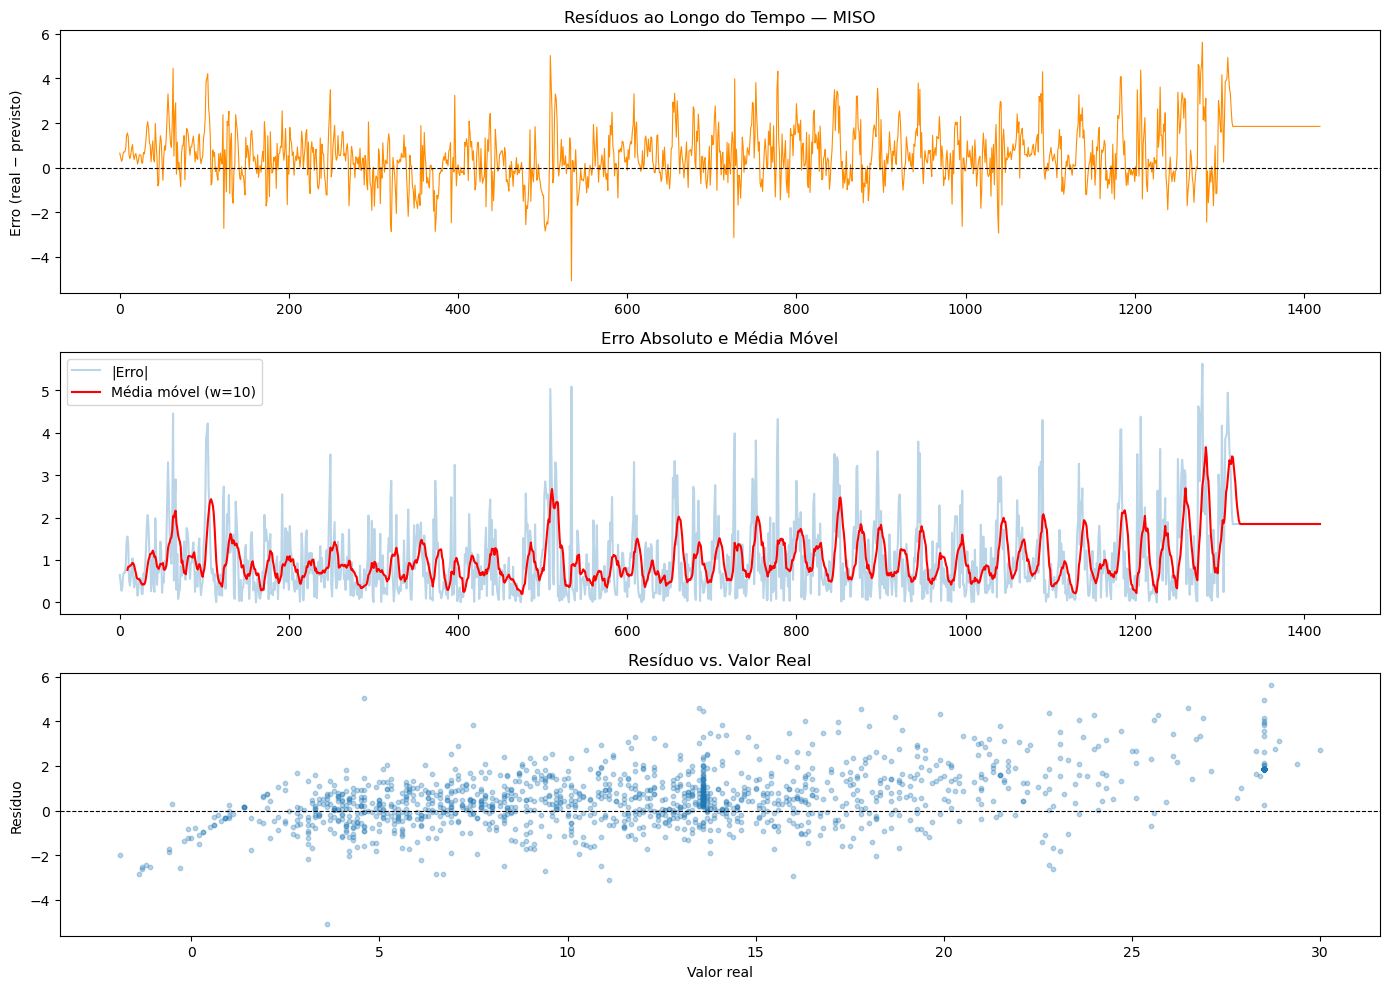

Média dos resíduos : 0.6198
Desvio dos resíduos: 1.2395
Maior erro absoluto: 5.6243 (índice 1280)


In [50]:
# --- Código fornecido ---
yp_miso_full = predict(model_miso, X_miso_te)

yt_orig = denorm(y_miso_te)
yp_orig = denorm(yp_miso_full)
residuals  = yt_orig - yp_orig
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(residuals, color='darkorange', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Resíduos ao Longo do Tempo — MISO', fontsize=12)
axes[0].set_ylabel('Erro (real − previsto)')

roll_e = pd.Series(abs_errors).rolling(10).mean()
axes[1].plot(abs_errors, alpha=0.3, label='|Erro|')
axes[1].plot(roll_e,     color='red', label='Média móvel (w=10)')
axes[1].set_title('Erro Absoluto e Média Móvel', fontsize=12)
axes[1].legend()

axes[2].scatter(yt_orig, residuals, alpha=0.3, s=10)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Resíduo vs. Valor Real', fontsize=12)
axes[2].set_xlabel('Valor real'); axes[2].set_ylabel('Resíduo')

plt.tight_layout(); plt.show()

print(f"Média dos resíduos : {residuals.mean():.4f}")
print(f"Desvio dos resíduos: {residuals.std():.4f}")
print(f"Maior erro absoluto: {abs_errors.max():.4f} (índice {abs_errors.argmax()})")

**Resposta Q14:**

**a) O erro do MISO é constante ao longo do tempo?**
> *Não parece ser. Os resíduos não se comportam como ruído branco homogêneo; eles apresentam flutuações e regiões mais problemáticas do que outras. O próprio resumo mostra isso: desvio dos resíduos ≈ 1.2395 e erro absoluto máximo ≈ 5.6243, o que sugere que há trechos de falha bem mais severa do que a média.*

**b) Existem regiões de falha sistemática? Compare com o que você observaria no modelo univariado.**
> *Sim, tudo indica que existem blocos temporais em que o erro se concentra mais. Isso é comum em séries ambientais, onde mudanças de regime térmico ou eventos locais tornam a previsão mais difícil. Em comparação com o univariado, o MISO deveria, em tese, lidar melhor com essas regiões por ter mais contexto. Mas, como o MISO já não superou o univariado no one-step deste notebook, parece que esse contexto extra não foi suficiente para estabilizar o erro em todos os trechos.*

**c) O gráfico de resíduo vs. valor real revela algum padrão (heteroscedasticidade, viés)?**
> *O resumo já sugere pelo menos um viés médio positivo nos resíduos: a média ficou em torno de +0.6198, ou seja, em média o resíduo y−
y
^
	​

 é positivo. Isso significa que o modelo está subestimando a temperatura de forma sistemática. Além disso, a presença de erros máximos relativamente altos sugere que a dispersão não é completamente uniforme. Portanto, há indícios de viés e de variabilidade do erro dependente da região da série.*

---
### Q15 — Limitações do MLP para Séries Temporais

Com base em todos os experimentos realizados, reflita sobre as limitações do MLP, tanto na versão univariada quanto nas versões MISO e MIMO.

**Resposta Q15:**

**a) Quais são as principais limitações do MLP no contexto de séries temporais univariadas?**
> *O MLP univariado transforma a história em um vetor fixo e perde parte da noção sequencial mais rica do processo. Ele depende fortemente da escolha da janela, não lida naturalmente com dependências longas e costuma funcionar melhor como aproximador local do que como modelo temporal profundo. Além disso, em previsão recursiva, ele é especialmente sensível à propagação de erro.*

**b) O uso de features exógenas (MISO) resolve alguma dessas limitações? Quais permanecem?**
> *Resolve parcialmente. As exógenas ampliam o contexto e podem ajudar a explicar mudanças que o passado do target, sozinho, não capta. Mas várias limitações permanecem: a memória ainda é fixa, o modelo continua sem mecanismo explícito de estado temporal, e a previsão recursiva continua vulnerável ao acúmulo de erro. Neste notebook, aliás, vimos um caso emblemático em que o MISO nem sequer superou o univariado no one-step.*

**c) A abordagem MIMO apresenta limitações específicas que o MISO não tem?**
> *Sim. O MIMO é mais ambicioso, porque prevê um bloco futuro inteiro. Isso pode melhorar a coerência temporal da saída, mas também torna o problema mais difícil de otimizar. A saída cresce bastante, a rede precisa distribuir capacidade entre várias tarefas simultâneas, e o custo de errar em múltiplas dimensões/horizontes aumenta. Ele ganha em elegância estrutural, mas perde em simplicidade.*

**d) Em quais situações o MLP (nas três variantes) não é adequado? Que arquiteturas seriam mais apropriadas?**
> *O MLP não é a melhor escolha quando a série possui dependências muito longas, múltiplas sazonalidades complexas, quebras estruturais fortes ou necessidade de previsão probabilística mais sofisticada. Nesses casos, arquiteturas como LSTM, GRU, TCN, Transformers temporais, ou modelos especializados como N-BEATS e N-HiTS tendem a ser mais apropriados. O MLP continua sendo um excelente laboratório didático e uma linha de base forte, mas não é, em geral, o ponto final da modelagem temporal.*